# Boston Housing: Gradient Boosting vs. a Tabular Foundation Model

**An annotated codebook.** We predict the corrected median home value (`cmedv`) for
Boston census tracts using two very different approaches:

1. **XGBoost** — a tuned gradient-boosted tree ensemble, the long-standing champion of tabular data.
2. **TabPFN** — a *tabular foundation model* that predicts with **no per-dataset training or tuning**.

The goal is to see how a modern foundation model stacks up against a carefully tuned classic
on a small, familiar dataset.

> **Running this on Google Colab?** For TabPFN, switch to a GPU runtime for speed:
> *Runtime → Change runtime type → Hardware accelerator → GPU*. It also runs fine on CPU for a
> dataset this small.

## 0. Setup

Colab already ships with `xgboost`, `scikit-learn`, `pandas`, and `matplotlib`, so we only need to
install **TabPFN**. The `-q` flag keeps the output quiet.

> **Why we pin `tabpfn==2.0.9`.** The newest TabPFN releases download a **gated** model from
> Hugging Face — every user would have to create an account, accept a license, and supply a token
> before it runs. That's painful in a classroom. The `2.x` line uses the **public, ungated**
> `TabPFN-v2` weights that download automatically with no login. If you *want* the latest model,
> use `pip install tabpfn`, then run `hf auth login` after accepting the terms at
> huggingface.co/Prior-Labs/tabpfn_3 .
>
> **Expected red warning — safe to ignore.** TabPFN 2.x requires `huggingface-hub<1`, so pip
> downgrades Colab's newer copy and prints a `dependency conflicts` block mentioning `gradio` and
> `transformers`. This notebook never imports those libraries, so the warning has **no effect** —
> just run the next cell. (No runtime restart needed.) Add `2>/dev/null` to the install line if
> you'd rather hide it during a live demo.

In [2]:
# Install TabPFN and Optuna. We pin TabPFN to 2.x on purpose: it pulls the PUBLIC
# TabPFN-v2 weights (no Hugging Face login needed), keeping a live demo friction-free.
# Optuna gives us Bayesian hyperparameter search for XGBoost.
# xgboost / scikit-learn / pandas / matplotlib already come with Colab.
#
# NOTE: pip will print a red "dependency conflicts" warning about gradio/transformers
# because TabPFN 2.x needs huggingface-hub<1. It's harmless here (we don't use those
# libraries). To silence it during a live demo, append  2>/dev/null  to the line below.
!pip install -q "tabpfn==2.0.9" 2>/dev/null
!pip install optuna -q

# First run downloads the model weights (~a few seconds); they're cached afterward.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.9/128.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42  # fix the seed everywhere so the demo is reproducible

# Version-safe RMSE helper (sklearn moved this around across versions)
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

## 1. Read in the data

On Colab the easiest path is the upload widget: run the cell, click **Choose Files**, and pick
`BostonHousing2.csv`. If you're running locally instead, the `except` branch just reads the file
from the current folder.

In [4]:
try:
    # --- Google Colab: interactive upload ---
    from google.colab import files
    import io
    uploaded = files.upload()                 # choose BostonHousing2.csv
    fname = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[fname]))
except ModuleNotFoundError:
    # --- Local / non-Colab fallback ---
    df = pd.read_csv("BostonHousing2.csv")

print("Loaded:", df.shape[0], "rows x", df.shape[1], "columns")
df.head()

Saving BostonHousing2.csv to BostonHousing2.csv
Loaded: 506 rows x 21 columns


,OBS.,TOWN,TOWN#,TRACT,LON,LAT,MEDV,CMEDV,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1,Nahant,0,2011,-70.955,42.2550,24.0,24.0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,2,Swampscott,1,2021,-70.950,42.2875,21.6,21.6,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,3,Swampscott,1,2022,-70.936,42.2830,34.7,34.7,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,4,Marblehead,2,2031,-70.928,42.2930,33.4,33.4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,5,Marblehead,2,2032,-70.922,42.2980,36.2,36.2,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


## 2. A quick look

The dataset has 506 rows (census tracts) and 21 columns. Beyond the classic 13 housing predictors,
this version (`BostonHousing2`) adds identifiers and geography: `OBS.`, `TOWN`, `TOWN#`, `TRACT`,
`LON`, `LAT`, plus **two** targets — `MEDV` (original) and `CMEDV` (corrected).

In [ ]:
df.info()

In [ ]:
df.describe().T

## 3. Choose the target and drop what we don't want

**Target:** `CMEDV` — the *corrected* median value (in $1000s).

**Columns we strip, and why:**

| Column | Why we drop it |
|:-------|:---------------|
| `MEDV` | The **uncorrected** target. It correlates ~0.999 with `CMEDV` — leaving it in is textbook **target leakage** (we'd just be copying the answer). |
| `TOWN`, `TOWN#` | Town name and its numeric code. These are **identifiers** that memorize *which* town a row is in rather than learning from its attributes. |
| `TRACT` | Census tract ID — another identifier, not a real feature. |
| `LON`, `LAT` | Longitude / latitude. We're modeling from housing attributes, not raw geolocation. |
| `OBS.` | Just the row index. |

That leaves the **13 canonical Boston Housing predictors**: `CRIM`, `ZN`, `INDUS`, `CHAS`, `NOX`,
`RM`, `AGE`, `DIS`, `RAD`, `TAX`, `PTRATIO`, `B`, `LSTAT`.

> Adjust `DROP_COLS` if you want to keep any of these — everything downstream follows from it.

In [5]:
TARGET = "CMEDV"

DROP_COLS = ["OBS.", "TOWN", "TOWN#", "TRACT", "LON", "LAT", "MEDV"]

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]

print("Features kept (", X.shape[1], "):", list(X.columns))
print("Target:", TARGET)

# Sanity check: everything left should be numeric with no missing values.
assert X.isnull().sum().sum() == 0, "Unexpected missing values!"
print("No missing values. All dtypes numeric:", X.dtypes.map(lambda t: np.issubdtype(t, np.number)).all())

Features kept ( 13 ): ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target: CMEDV
No missing values. All dtypes numeric: True


### A word on the leakage we just avoided

It's worth *showing* students why `MEDV` had to go — its correlation with the target is essentially 1.

In [ ]:
print("corr(MEDV, CMEDV) =", round(df["MEDV"].corr(df[TARGET]), 4))

## 4. Train / test split

A single hold-out split (80/20) keeps the demo simple and gives both models the **exact same**
test set, so the comparison at the end is fair. XGBoost will additionally use cross-validation
*inside* the training set for tuning.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (404, 13)  Test: (102, 13)


## 5. Model 1 — Tuned XGBoost

### 5a. A baseline first

Before tuning, fit XGBoost with default-ish settings. Always know what "out of the box" looks like
so you can tell whether tuning actually bought you anything.

In [7]:
from xgboost import XGBRegressor

xgb_base = XGBRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_base.fit(X_train, y_train)
base_pred = xgb_base.predict(X_test)

print("Baseline XGBoost")
print(f"  RMSE: {rmse(y_test, base_pred):.3f}")
print(f"  MAE : {mean_absolute_error(y_test, base_pred):.3f}")
print(f"  R^2 : {r2_score(y_test, base_pred):.3f}")

Baseline XGBoost
  RMSE: 2.851
  MAE : 2.034
  R^2 : 0.890


### 5b. Hyperparameter tuning with Bayesian optimization (Optuna)

Random or grid search sample the space **blindly**. **Bayesian optimization** instead builds a
running model of *"which regions of the search space look promising"* and concentrates its trials
there — so for the **same budget** it usually finds a better configuration. Since TabPFN gets no
tuning at all, giving XGBoost this stronger search is the *fairer* comparison.

We use **Optuna** with its default **TPE** (Tree-structured Parzen Estimator) sampler. The objective
is the **5-fold cross-validated RMSE on the training set only** — the test set stays untouched.

- `n_estimators`, `learning_rate` — how many trees and how big each step.
- `max_depth`, `min_child_weight` — tree complexity / when to stop splitting.
- `subsample`, `colsample_bytree` — row/column sampling (regularization via randomness).
- `gamma`, `reg_alpha`, `reg_lambda` — explicit regularization.

> **Caveat to raise with students:** optimizing hard against a CV score invites a mild
> *winner's curse* — the config that wins on the validation folds isn't guaranteed to win on the
> test set. That's a big reason the repeated-splits check in Section 9 exists. The fully rigorous
> fix is *nested* cross-validation, which we skip here for speed.

In [8]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)  # keep the demo output tidy

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 200, 1200, step=100),
        "learning_rate":    trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    model = XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
    # Cross-validated RMSE on the TRAINING set only (never touches X_test).
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring="neg_root_mean_squared_error")
    return -scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)  # reproducible Bayesian search
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=40)   # lower for a faster live run; raise to search harder

best_params = study.best_params
print("Best CV RMSE:", round(study.best_value, 3))
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

Best CV RMSE: 3.147
Best params:
  n_estimators: 1000
  learning_rate: 0.01774645673675725
  max_depth: 4
  min_child_weight: 1
  subsample: 0.773028071429741
  colsample_bytree: 0.86476534689626
  gamma: 0.7159870763981409
  reg_alpha: 0.44281420761839224
  reg_lambda: 1.2184536382987963


### 5b-ii. Watch the search converge

Optuna records every trial, so we can plot the **best RMSE found so far** against trial number.
A curve that drops then flattens tells you the search has more or less settled.

/tmp/ipykernel_1052/2673697618.py:3: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)


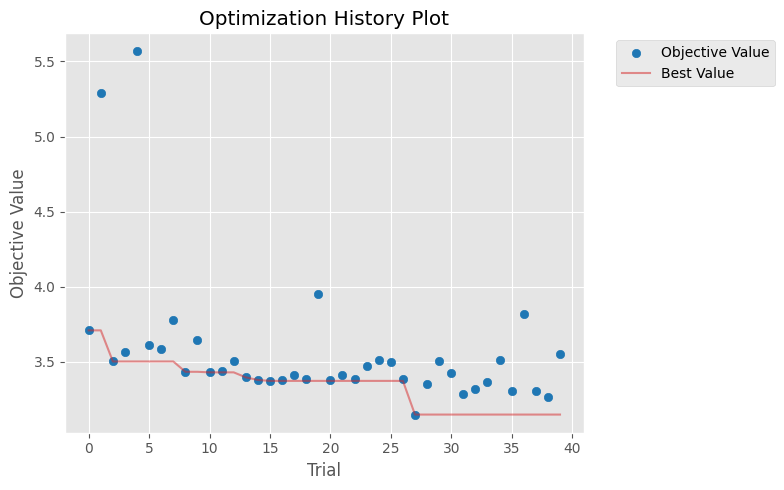

In [9]:
try:
    from optuna.visualization.matplotlib import plot_optimization_history
    ax = plot_optimization_history(study)
    ax.figure.set_size_inches(8, 5)
    plt.tight_layout()
    plt.show()
except Exception as e:
    # Fallback: plot the running minimum by hand if the optuna plotting extra is missing.
    vals = [t.value for t in study.trials if t.value is not None]
    running_best = np.minimum.accumulate(vals)
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(vals) + 1), vals, "o", alpha=0.4, label="trial RMSE")
    plt.plot(range(1, len(vals) + 1), running_best, "-", label="best so far")
    plt.xlabel("Trial"); plt.ylabel("CV RMSE"); plt.legend()
    plt.title("Optuna optimization history"); plt.tight_layout(); plt.show()

### 5c. Evaluate the tuned model on the hold-out test set

We refit XGBoost on the full training set using the best hyperparameters Optuna found, then score
it **once** on the held-out test set.

In [10]:
xgb_best = XGBRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
xgb_best.fit(X_train, y_train)
xgb_pred = xgb_best.predict(X_test)

xgb_metrics = {
    "RMSE": rmse(y_test, xgb_pred),
    "MAE":  mean_absolute_error(y_test, xgb_pred),
    "R2":   r2_score(y_test, xgb_pred),
}
print("Tuned XGBoost")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.3f}")

Tuned XGBoost
  RMSE: 2.636
  MAE: 1.779
  R2: 0.906


### 5d. Which features drive the predictions?

One nice property of tree ensembles is a built-in notion of feature importance. For Boston Housing
you'll typically see `LSTAT` (% lower-status population) and `RM` (rooms per dwelling) dominate.

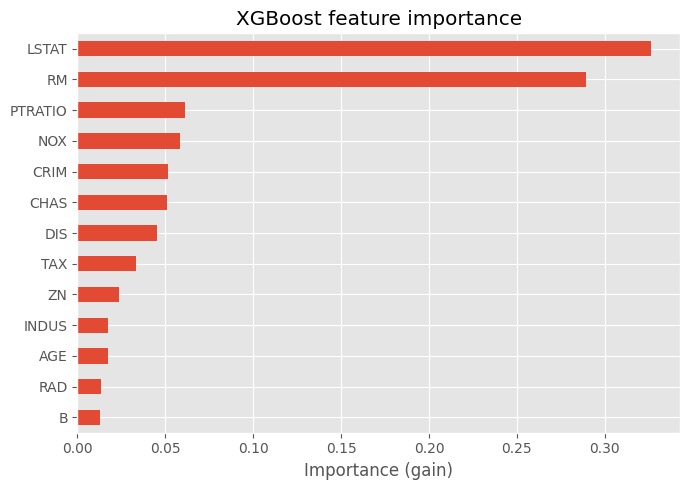

In [11]:
importances = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
importances.plot(kind="barh")
plt.title("XGBoost feature importance")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

## 6. Model 2 — TabPFN (a tabular foundation model)

Now the contrast. **TabPFN** was *pretrained once* on millions of synthetic datasets to learn the
general skill of "given labeled rows, predict a new row." For us that means:

- **No hyperparameter search.** We just instantiate and fit.
- **`.fit()` doesn't really train** — it loads the training rows as *context*. The prediction for
  each test row happens in a single forward pass (**in-context learning**).
- Our data is comfortably inside TabPFN's supported range (it targets up to ~10k rows and
  ~500 features; we have 506 rows and 13 features).

The API is deliberately scikit-learn-shaped: `TabPFNRegressor()`, `.fit()`, `.predict()`.

In [12]:
import torch
from tabpfn import TabPFNRegressor

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tabpfn = TabPFNRegressor(device=device)
tabpfn.fit(X_train, y_train)      # loads context — no gradient descent here
tabpfn_pred = tabpfn.predict(X_test)

tabpfn_metrics = {
    "RMSE": rmse(y_test, tabpfn_pred),
    "MAE":  mean_absolute_error(y_test, tabpfn_pred),
    "R2":   r2_score(y_test, tabpfn_pred),
}
print("TabPFN (no tuning)")
for k, v in tabpfn_metrics.items():
    print(f"  {k}: {v:.3f}")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/tabpfn/base.py:101: UserWarning: Downloading model to /root/.cache/tabpfn/tabpfn-v2-regressor.ckpt.
  model, bardist, config_ = load_model_criterion_config(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v2-regressor.ckpt:   0%|          | 0.00/44.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

TabPFN (no tuning)
  RMSE: 2.001
  MAE: 1.421
  R2: 0.946


### 6b. (Optional) Predictive uncertainty

Because TabPFN approximates a *Bayesian* predictor, it can return a full predictive distribution,
not just a point estimate. Here we pull 10th/90th-percentile bounds to get an 80% interval for the
first few test tracts. (Wrapped in `try/except` so the notebook still runs if the API differs across
TabPFN versions.)

In [13]:
try:
    q = tabpfn.predict(X_test, output_type="quantiles", quantiles=[0.1, 0.9])
    lo, hi = np.asarray(q[0]), np.asarray(q[1])
    preview = pd.DataFrame({
        "actual":     y_test.values[:8],
        "prediction": tabpfn_pred[:8],
        "p10":        lo[:8],
        "p90":        hi[:8],
    }).round(2)
    print("80% predictive intervals (first 8 test tracts):")
    display(preview)
except Exception as e:
    print("Quantile API not available in this TabPFN version — skipping. Details:", e)

80% predictive intervals (first 8 test tracts):


,actual,prediction,p10,p90
0,23.6,24.629999,22.250000,27.209999
1,32.4,31.670000,29.139999,34.060001
2,13.6,15.640000,12.900000,18.340000
3,22.8,23.320000,21.750000,24.910000
4,16.1,17.309999,14.570000,20.320000
5,20.0,21.209999,18.780001,23.700001
6,17.8,18.490000,16.309999,20.629999
7,14.0,16.059999,13.410000,18.580000


## 7. Head-to-head comparison

Same test set, same metrics. Lower RMSE/MAE is better; higher R² is better.

In [14]:
comparison = pd.DataFrame(
    {
        "Baseline XGBoost": {
            "RMSE": rmse(y_test, base_pred),
            "MAE":  mean_absolute_error(y_test, base_pred),
            "R2":   r2_score(y_test, base_pred),
        },
        "Tuned XGBoost": xgb_metrics,
        "TabPFN": tabpfn_metrics,
    }
).T.round(3)

comparison

,RMSE,MAE,R2
Baseline XGBoost,2.851,2.034,0.890
Tuned XGBoost,2.636,1.779,0.906
TabPFN,2.001,1.421,0.946


### Predicted vs. actual

A visual gut-check. Points hugging the diagonal (dashed line) mean accurate predictions.

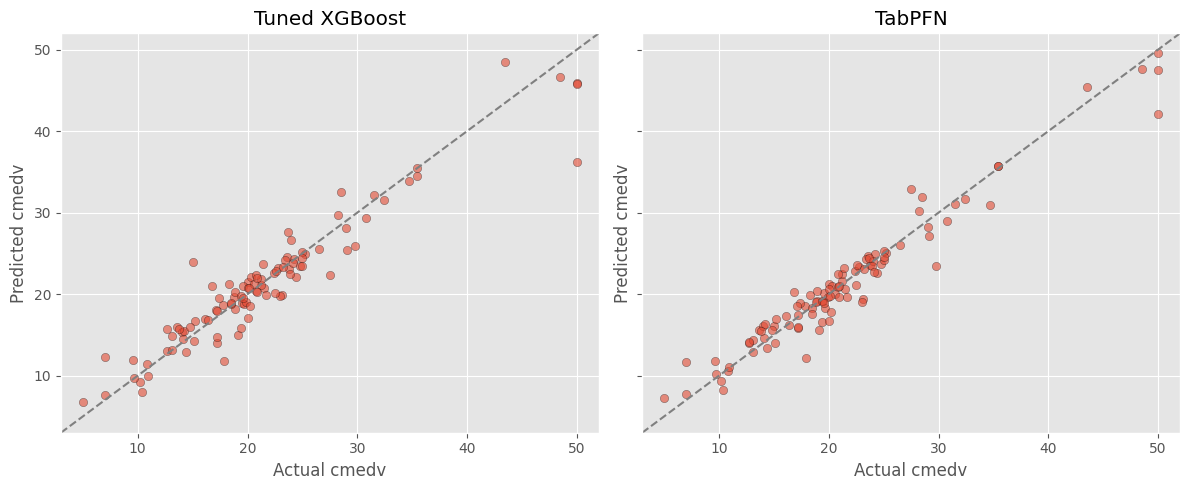

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
lims = [y_test.min() - 2, y_test.max() + 2]

for ax, pred, name in [
    (axes[0], xgb_pred, "Tuned XGBoost"),
    (axes[1], tabpfn_pred, "TabPFN"),
]:
    ax.scatter(y_test, pred, alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.plot(lims, lims, "--", color="gray")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual cmedv")
    ax.set_ylabel("Predicted cmedv")
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 8. Feature importance — do the two models agree?

The tree model gave us a *built-in* importance in Section 5d, but that number is XGBoost-specific
(it counts how much each feature reduced the loss when it was split on). **TabPFN has no built-in
importance at all.** So to compare the two on equal terms we use a **model-agnostic** method:
**permutation importance**.

The idea is simple: take the fitted model, **shuffle one feature's column** in the test set, and see
how much the RMSE gets worse. If breaking a feature badly hurts predictions, the model was relying on
it. We run the *identical* procedure on both models, so any difference reflects the **models**, not
the method.

In [16]:
from sklearn.inspection import permutation_importance

# NOTE: permutation importance re-predicts once per (feature x repeat). TabPFN predicts via a
# forward pass over the training context, so this is the slowest cell for TabPFN on CPU.
# Lower n_repeats (or use a GPU runtime) if it drags during a live demo.
perm_kwargs = dict(n_repeats=10, random_state=RANDOM_STATE,
                   scoring="neg_root_mean_squared_error")

perm_xgb = permutation_importance(xgb_best, X_test, y_test, **perm_kwargs)
perm_tab = permutation_importance(tabpfn,   X_test, y_test, **perm_kwargs)

importance = pd.DataFrame(
    {"XGBoost": perm_xgb.importances_mean, "TabPFN": perm_tab.importances_mean},
    index=X.columns,
).sort_values("XGBoost")

importance.round(3)

,XGBoost,TabPFN
CHAS,0.002,0.003
ZN,0.020,0.060
RAD,0.029,0.491
INDUS,0.061,0.151
B,0.150,0.279
TAX,0.166,1.215
PTRATIO,0.295,0.437
AGE,0.537,1.504
NOX,0.586,1.149
CRIM,0.700,0.498


### Side by side

Both bars are on the same scale: *"how many RMSE units do we lose if this feature is scrambled?"*

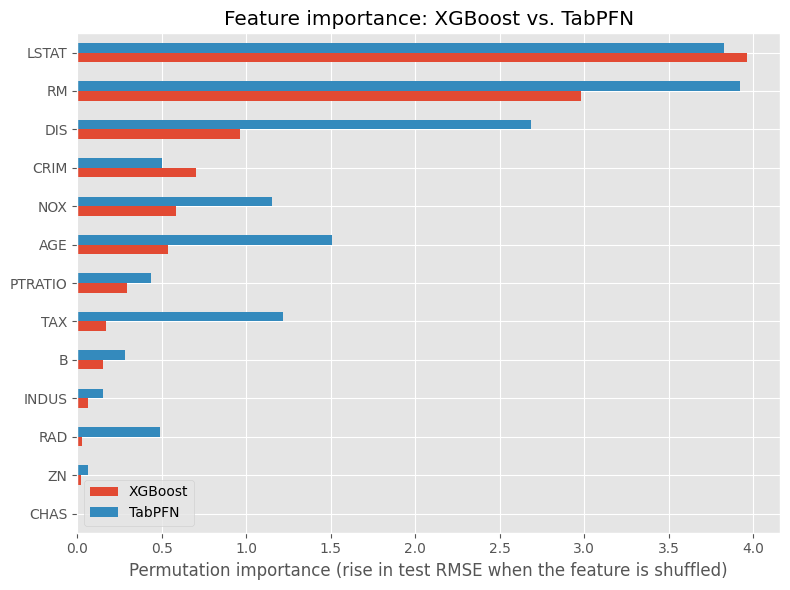

In [17]:
ax = importance.plot(kind="barh", figsize=(8, 6))
ax.set_xlabel("Permutation importance (rise in test RMSE when the feature is shuffled)")
ax.set_title("Feature importance: XGBoost vs. TabPFN")
ax.axvline(0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

### Do they agree? Quantify it

Eyeballing bars is nice, but let's put a number on the agreement with the **Spearman rank
correlation** of the two importance orderings (1.0 = identical ranking, 0 = unrelated).

In [18]:
from scipy.stats import spearmanr

rho, _ = spearmanr(importance["XGBoost"], importance["TabPFN"])
print(f"Spearman rank correlation of feature importances: {rho:.2f}")

top_xgb = importance["XGBoost"].sort_values(ascending=False).head(3).index.tolist()
top_tab = importance["TabPFN"].sort_values(ascending=False).head(3).index.tolist()
print("Top 3 by XGBoost:", top_xgb)
print("Top 3 by TabPFN :", top_tab)

Spearman rank correlation of feature importances: 0.89
Top 3 by XGBoost: ['LSTAT', 'RM', 'DIS']
Top 3 by TabPFN : ['RM', 'LSTAT', 'DIS']


**Reading the result.** Two very differently-built models — a boosted tree ensemble and a
pretrained transformer — typically put the *same* couple of features on top here (for Boston Housing,
`LSTAT` and `RM`). When independent models agree on what matters, that's reassuring evidence the
signal is **real in the data**, not an artifact of one model family. Expect more disagreement among
the weak, middle-of-the-pack features.

> **Caveat for students:** permutation importance can be *fooled by correlated features*. If two
> columns carry similar information (e.g., `TAX` and `RAD`), shuffling just one leaves the other to
> compensate, so both look less important than they really are. It measures *"what this model uses,"*
> not ground-truth causal importance.

## 9. How stable is this? Repeated splits

Everything above rests on **one** 80/20 split with ~100 test rows — small enough that the winner can
flip if we just change the random seed. To see how much the comparison actually wobbles, we repeat it
over several splits and report **mean ± standard deviation** for each metric.

**A deliberate shortcut:** we do *not* re-run the hyperparameter search inside every split (that would
be `N_REPEATS` × 40 × 5 model fits — too slow for a live demo, and it risks leaking test information
into tuning). Instead we **reuse the winning XGBoost hyperparameters** found earlier and simply refit
them on each new split. TabPFN needs no tuning, so it's naturally fair here. Read this as *"given a
good configuration, how variable is each model?"* rather than a full nested-cross-validation study.

In [19]:
from sklearn.base import clone

N_REPEATS = 10   # lower to 5 for a faster live run; raise for tighter estimates
SEEDS = list(range(N_REPEATS))

# Reuse the hyperparameters chosen by the Optuna search above.
xgb_template = XGBRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)

records = []
for seed in SEEDS:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, random_state=seed)

    # --- Tuned XGBoost (refit with the fixed best params) ---
    xgb_m = clone(xgb_template).fit(Xtr, ytr)
    xp = xgb_m.predict(Xte)
    records.append({"model": "Tuned XGBoost", "seed": seed,
                    "RMSE": rmse(yte, xp), "MAE": mean_absolute_error(yte, xp),
                    "R2": r2_score(yte, xp)})

    # --- TabPFN (no tuning) ---
    tp_m = TabPFNRegressor(device=device).fit(Xtr, ytr)
    tp = tp_m.predict(Xte)
    records.append({"model": "TabPFN", "seed": seed,
                    "RMSE": rmse(yte, tp), "MAE": mean_absolute_error(yte, tp),
                    "R2": r2_score(yte, tp)})

    print(f"seed {seed:>2} done")

results = pd.DataFrame(records)
print("\nCollected", len(results), "runs.")
results.head()

seed  0 done
seed  1 done
seed  2 done
seed  3 done
seed  4 done
seed  5 done
seed  6 done
seed  7 done
seed  8 done
seed  9 done

Collected 20 runs.


,model,seed,RMSE,MAE,R2
0,Tuned XGBoost,0,4.560792,2.617332,0.741544
1,TabPFN,0,4.108465,2.293091,0.790268
2,Tuned XGBoost,1,2.853585,2.202599,0.917604
3,TabPFN,1,2.382345,1.765705,0.942571
4,Tuned XGBoost,2,2.455091,1.733470,0.928467


### Mean ± standard deviation across the splits

The `±` column is the spread you'd expect just from re-shuffling the data — often as large as the gap
between the two models, which is exactly the point.

In [20]:
summary = (
    results
    .groupby("model")[["RMSE", "MAE", "R2"]]
    .agg(["mean", "std"])
    .round(3)
)
# Flatten to a tidy "mean ± std" table
tidy = pd.DataFrame(index=summary.index)
for metric in ["RMSE", "MAE", "R2"]:
    tidy[metric] = (summary[(metric, "mean")].map("{:.3f}".format)
                    + " ± "
                    + summary[(metric, "std")].map("{:.3f}".format))
tidy

,RMSE,MAE,R2
model,,,
TabPFN,2.706 ± 0.734,1.709 ± 0.270,0.906 ± 0.059
Tuned XGBoost,3.096 ± 0.688,2.023 ± 0.286,0.881 ± 0.061


### Distribution of RMSE across splits

A boxplot makes the overlap (or separation) obvious at a glance.

/tmp/ipykernel_1052/1645246705.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showmeans=True)


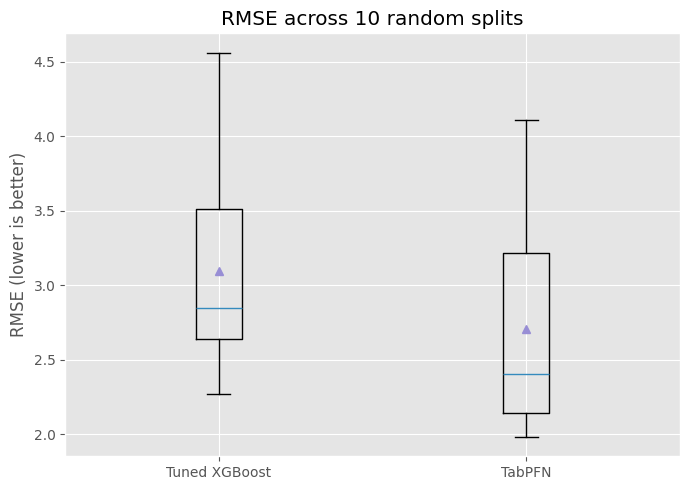

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ["Tuned XGBoost", "TabPFN"]
data = [results.loc[results.model == m, "RMSE"].values for m in order]
ax.boxplot(data, labels=order, showmeans=True)
ax.set_ylabel("RMSE (lower is better)")
ax.set_title(f"RMSE across {N_REPEATS} random splits")
plt.tight_layout()
plt.show()

## 10. Takeaways for discussion

- **Effort asymmetry.** The XGBoost result came from a 40-trial Bayesian (Optuna) cross-validated
  search; the TabPFN result came from `fit` + `predict` with **zero tuning**. Ask students whether
  the accuracy difference (either way) justifies the effort difference.
- **This is TabPFN's sweet spot.** Small, clean, purely numeric tables are exactly where tabular
  foundation models shine. On millions of rows, XGBoost would still be the pragmatic choice.
- **A tuned GBDT is a serious opponent.** "Beats XGBoost" headlines usually mean *default*
  XGBoost — here we tuned it, which is the fairer comparison.
- **Reproducibility caveat.** With only ~100 test rows, results wobble with the random seed —
  which is exactly why Section 9 repeated the comparison over several splits. Notice how often the
  mean gap is comparable to the ± spread: on data this small, "which model wins" is partly luck of
  the split.

**Next steps to try live:** change `RANDOM_STATE`, expand `DROP_COLS` (e.g., keep `LON`/`LAT`),
or increase `n_iter` in the search and see what moves.

# 11. Exercise
Find a data set that is important in your work. run the same code on the data and see what comes out.If you run this on a CPU, some parts will take more time. You can speed up things a bit by lowering `n_repeats` and `N_REPEATS`.